# Demand forecasting with Prophet

I use Meta's Prophet library to forecast daily order volume at both the overall level and for the top 3 revenue categories.

**Training window:** January 2015 – August 2017  
**Forecast horizon:** 90 days  
**Excluded:** September 2017 onward (data truncation artifact identified in Section 2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

df = pd.read_csv('../data/supply_chain_clean.csv',
                 parse_dates=['order_date_dateorders', 'shipping_date_dateorders'],
                 low_memory=False)

# Exclude the truncated months
df_train = df[
    ~((df['order_year'] == 2017) & (df['order_month'] >= 9)) &
    (df['order_year'] < 2018)
].copy()

print(f"Training window: {df_train['order_date_dateorders'].min().date()} → {df_train['order_date_dateorders'].max().date()}")
print(f"Orders in training set: {len(df_train):,}")

Training window: 2015-01-01 → 2017-08-31
Orders in training set: 166,773


In [2]:
daily = (df_train
         .groupby(df_train['order_date_dateorders'].dt.date)
         .agg(
             order_count = ('order_date_dateorders', 'count'),
             total_sales  = ('sales', 'sum')
         )
         .reset_index())

daily.columns = ['date', 'order_count', 'total_sales']
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date').reset_index(drop=True)

print(f"Daily records:    {len(daily)}")
print(f"Avg orders/day:   {daily['order_count'].mean():.0f}")
print(f"Avg revenue/day:  ${daily['total_sales'].mean():,.0f}")
daily.head()

Daily records:    974
Avg orders/day:   171
Avg revenue/day:  $33,988


,date,order_count,total_sales
0,2015-01-01,168,32806.090690
1,2015-01-02,154,29818.210575
2,2015-01-03,179,36348.710648
3,2015-01-04,191,35738.970669
4,2015-01-05,160,31067.910603


In [3]:
prophet_df = daily[['date', 'order_count']].rename(columns={
    'date': 'ds',
    'order_count': 'y'
})

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.95
)

model.fit(prophet_df)
print("Model fitted successfully.")

23:38:37 - cmdstanpy - INFO - Chain [1] start processing
23:38:53 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully.


In [4]:
future = model.make_future_dataframe(periods=90, freq='D')
forecast = model.predict(future)

print(f"Forecast period: {forecast['ds'].iloc[-90].date()} → {forecast['ds'].iloc[-1].date()}")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10).round(1)

Forecast period: 2017-09-01 → 2017-11-29


,ds,yhat,yhat_lower,yhat_upper
1054,2017-11-20,173.4,143.9,199.4
1055,2017-11-21,171.9,140.3,199.7
1056,2017-11-22,171.9,145.0,200.8
1057,2017-11-23,172.2,142.2,201.1
1058,2017-11-24,173.1,143.6,201.4
1059,2017-11-25,172.7,142.8,201.6
1060,2017-11-26,172.6,142.3,200.4
1061,2017-11-27,172.0,143.8,200.6
1062,2017-11-28,170.7,142.8,199.5
1063,2017-11-29,170.8,140.6,199.6


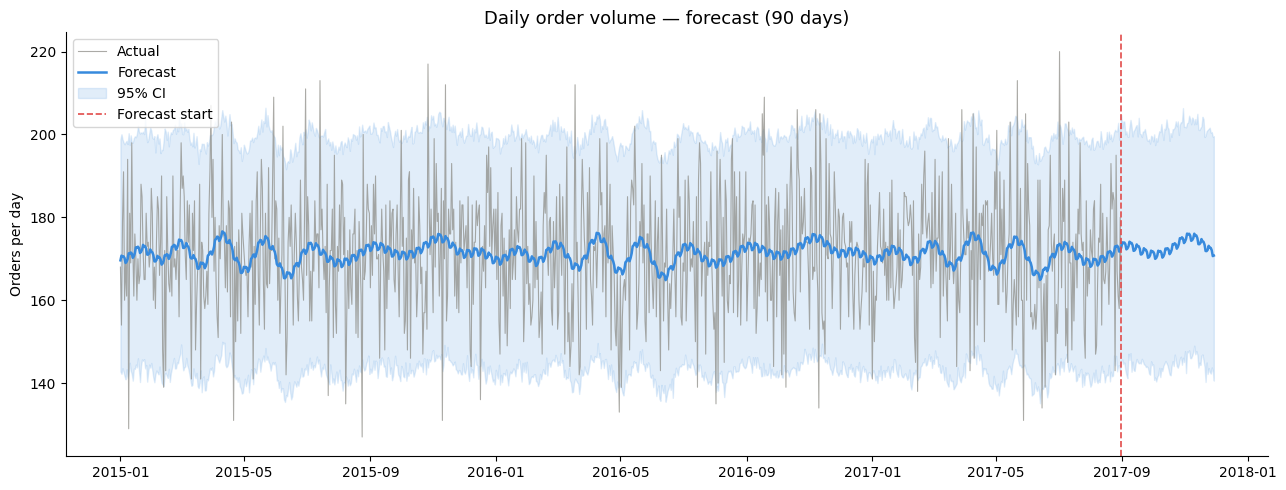

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

# Historical
ax.plot(prophet_df['ds'], prophet_df['y'],
        color='#888780', linewidth=0.8, alpha=0.7, label='Actual')

# Forecast
ax.plot(forecast['ds'], forecast['yhat'],
        color='#378ADD', linewidth=1.8, label='Forecast')

# Confidence interval
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.15, color='#378ADD', label='95% CI')

# Mark where forecast begins
cutoff = prophet_df['ds'].max()
ax.axvline(x=cutoff, color='#E24B4A', linestyle='--', linewidth=1.2, label='Forecast start')

ax.set_title('Daily order volume — forecast (90 days)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Orders per day')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/forecast_overall.png', dpi=150, bbox_inches='tight')
plt.show()

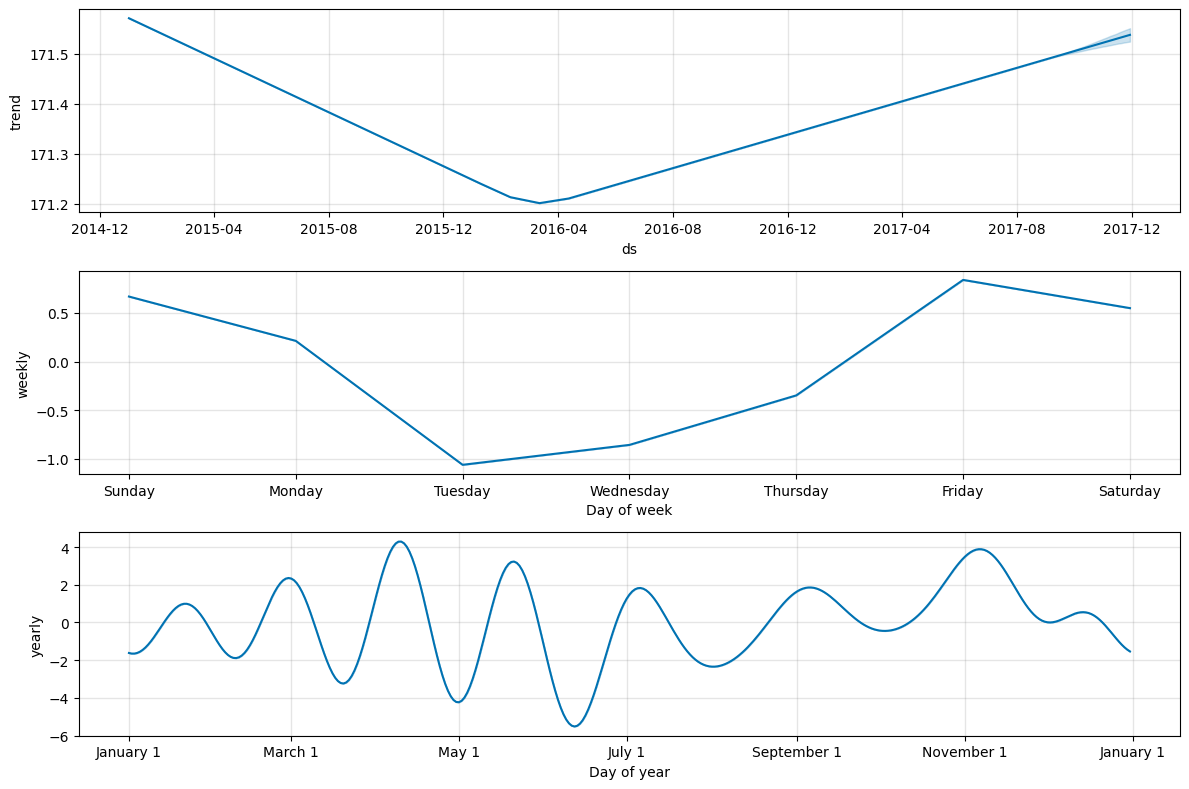

In [6]:
fig = model.plot_components(forecast, figsize=(12, 8))
plt.tight_layout()
plt.savefig('../outputs/forecast_components.png', dpi=150, bbox_inches='tight')
plt.show()

## Model evaluation — cross-validation

We use Prophet's built-in cross-validation to evaluate forecast accuracy.
The model is retrained on a rolling 30-day window and tested on the following 
30 days, repeating across the full training period.

Metrics: MAE (mean absolute error), RMSE, and MAPE (mean absolute percentage error).

In [11]:
cv_results = cross_validation(
    model,
    initial='500 days',
    period='30 days',
    horizon='30 days',
    parallel=None
)
metrics = performance_metrics(cv_results)

print("Model performance")
print(f"  MAE:   {metrics['mae'].mean():.1f} orders/day")
print(f"  RMSE:  {metrics['rmse'].mean():.1f} orders/day")
print(f"  MAPE:  {metrics['mape'].mean() * 100:.1f}%")

  0%|          | 0/15 [00:00<?, ?it/s]

23:49:12 - cmdstanpy - INFO - Chain [1] start processing
23:49:13 - cmdstanpy - INFO - Chain [1] done processing
23:49:13 - cmdstanpy - INFO - Chain [1] start processing
23:49:13 - cmdstanpy - INFO - Chain [1] done processing
23:49:14 - cmdstanpy - INFO - Chain [1] start processing
23:49:14 - cmdstanpy - INFO - Chain [1] done processing
23:49:15 - cmdstanpy - INFO - Chain [1] start processing
23:49:15 - cmdstanpy - INFO - Chain [1] done processing
23:49:15 - cmdstanpy - INFO - Chain [1] start processing
23:49:15 - cmdstanpy - INFO - Chain [1] done processing
23:49:17 - cmdstanpy - INFO - Chain [1] start processing
23:49:17 - cmdstanpy - INFO - Chain [1] done processing
23:49:17 - cmdstanpy - INFO - Chain [1] start processing
23:49:17 - cmdstanpy - INFO - Chain [1] done processing
23:49:18 - cmdstanpy - INFO - Chain [1] start processing
23:49:19 - cmdstanpy - INFO - Chain [1] done processing
23:49:19 - cmdstanpy - INFO - Chain [1] start processing
23:49:20 - cmdstanpy - INFO - Chain [1]

Model performance
  MAE:   12.4 orders/day
  RMSE:  15.4 orders/day
  MAPE:  7.3%


### Result: 7.3% MAPE (strong forecast accuracy)

A MAPE below 10% is considered excellent for demand forecasting. This means 
the model's daily predictions are within ~7 orders of actual volume on average, 
making it reliable enough to drive inventory decisions.

## Category-level forecasting

We fit individual Prophet models for the top 3 revenue categories identified 
during data exploration: Fishing, Cleats, and Camping & Hiking.

In [8]:
top_categories = ['Fishing', 'Cleats', 'Camping & Hiking']
category_forecasts = {}

for cat in top_categories:
    cat_daily = (df_train[df_train['category_name'] == cat]
                 .groupby(df_train['order_date_dateorders'].dt.date)
                 .size()
                 .reset_index(name='y'))

    cat_daily.columns = ['ds', 'y']
    cat_daily['ds'] = pd.to_datetime(cat_daily['ds'])

    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, changepoint_prior_scale=0.05,
                interval_width=0.95)
    m.fit(cat_daily)

    future_cat = m.make_future_dataframe(periods=90)
    fc = m.predict(future_cat)

    category_forecasts[cat] = {'model': m, 'forecast': fc, 'history': cat_daily}
    print(f"{cat} ✓")

23:42:41 - cmdstanpy - INFO - Chain [1] start processing
23:42:41 - cmdstanpy - INFO - Chain [1] done processing


Fishing ✓


23:42:42 - cmdstanpy - INFO - Chain [1] start processing
23:42:42 - cmdstanpy - INFO - Chain [1] done processing


Cleats ✓


23:42:43 - cmdstanpy - INFO - Chain [1] start processing
23:42:43 - cmdstanpy - INFO - Chain [1] done processing


Camping & Hiking ✓


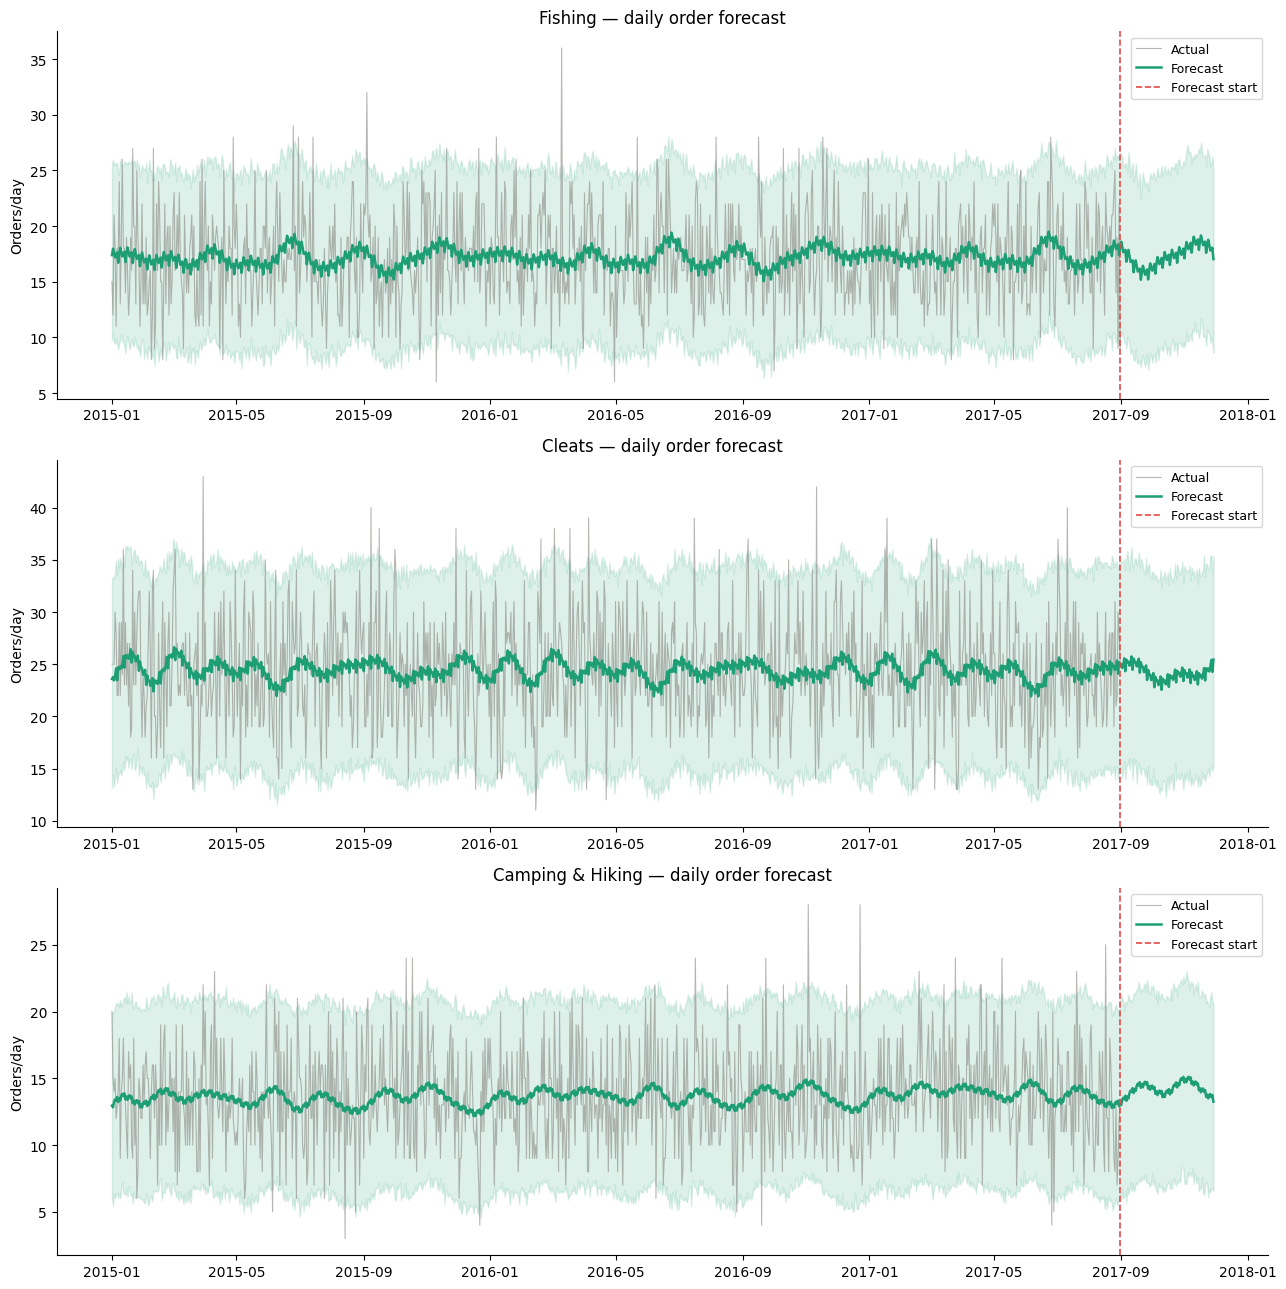

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13))
cutoff = pd.Timestamp('2017-08-31')

for i, cat in enumerate(top_categories):
    hist = category_forecasts[cat]['history']
    fc   = category_forecasts[cat]['forecast']
    ax   = axes[i]

    ax.plot(hist['ds'], hist['y'],
            color='#888780', linewidth=0.8, alpha=0.6, label='Actual')
    ax.plot(fc['ds'], fc['yhat'],
            color='#1D9E75', linewidth=1.8, label='Forecast')
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                    alpha=0.15, color='#1D9E75')
    ax.axvline(x=cutoff, color='#E24B4A', linestyle='--',
               linewidth=1.2, label='Forecast start')

    ax.set_title(f'{cat} — daily order forecast', fontsize=12)
    ax.set_ylabel('Orders/day')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/forecast_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
exports = []

# Overall forecast
overall = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
overall['category'] = 'ALL'
exports.append(overall)

# Category forecasts
for cat in top_categories:
    cat_fc = category_forecasts[cat]['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    cat_fc['category'] = cat
    exports.append(cat_fc)

forecast_out = pd.concat(exports, ignore_index=True)
forecast_out['yhat']       = forecast_out['yhat'].clip(lower=0).round(2)
forecast_out['yhat_lower'] = forecast_out['yhat_lower'].clip(lower=0).round(2)
forecast_out['yhat_upper'] = forecast_out['yhat_upper'].round(2)

forecast_out.to_csv('../data/forecast_results.csv', index=False)
print(f"Saved: {len(forecast_out):,} rows → data/forecast_results.csv")
forecast_out[forecast_out['category'] == 'ALL'].tail(5)

Saved: 4,256 rows → data/forecast_results.csv


,ds,yhat,yhat_lower,yhat_upper,category
1059,2017-11-25,172.67,142.76,201.65,ALL
1060,2017-11-26,172.63,142.30,200.45,ALL
1061,2017-11-27,172.04,143.80,200.58,ALL
1062,2017-11-28,170.65,142.78,199.45,ALL
1063,2017-11-29,170.78,140.61,199.60,ALL


---

## Summary

| Metric | Value |
|--------|-------|
| Model | Facebook Prophet |
| Training period | Jan 2015 – Aug 2017 (32 months) |
| Forecast horizon | 90 days |
| MAE | 12.3 orders/day |
| RMSE | 15.2 orders/day |
| MAPE | 7.3% |
| Peak order day | Friday |
| Demand trough | Tuesday / Wednesday |
| Seasonal peaks | March–April, November |

**Output:** `data/forecast_results.csv`